In [1]:
import numpy as np #https://chatgpt.com/c/68d425ed-c26c-8321-b94a-fb2faa041221
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, recall_score, precision_score, accuracy_score, roc_auc_score,
    average_precision_score, classification_report, confusion_matrix
)
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
%pwd

'C:\\Users\\anton\\Documents\\programming\\python\\ML\\QNN'

In [2]:

# =====================
# 1. Dataset
# =====================
df = pd.read_csv("../creditcard.csv")

X = df.drop(columns=["Class"]).values
y = df["Class"].values

In [3]:

scaler = StandardScaler()
X = scaler.fit_transform(X)

# índices fraude / não fraude
fraudes = np.where(y == 1)[0]
nao_fraudes = np.where(y == 0)[0]

# treino
train_fraudes = np.random.choice(fraudes, 390, replace=False)
train_nao_fraudes = np.random.choice(nao_fraudes, 1000, replace=False)

# teste
test_nao_fraudes = np.random.choice(
    np.setdiff1d(nao_fraudes, train_nao_fraudes), 1000, replace=False
)
test_fraudes = np.setdiff1d(fraudes, train_fraudes)

train_idx = np.concatenate([train_fraudes, train_nao_fraudes])
test_idx = np.concatenate([test_fraudes, test_nao_fraudes])

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# tensores
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # (batch, seq=1, features)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)


In [4]:

# =====================
# 2. LSTM à mão (Esposito)
# =====================
class MyLSTM(nn.Module):
    def __init__(self, input_sz, hidden_sz, output_size=1):
        super().__init__()
        self.input_sz = input_sz
        self.hidden_size = hidden_sz

        # parâmetros
        self.W = nn.Parameter(torch.Tensor(input_sz, hidden_sz * 4))
        self.U = nn.Parameter(torch.Tensor(hidden_sz, hidden_sz * 4))
        self.bias = nn.Parameter(torch.Tensor(hidden_sz * 4))

        self.fc = nn.Linear(hidden_sz, output_size)
        self.sigmoid = nn.Sigmoid()
        self.init_weights()

    def init_weights(self):
        stdv = 1.0 / np.sqrt(self.hidden_size)
        for weight in self.parameters():
            weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        batch_sz, seq_len, _ = x.size()
        h_t = torch.zeros(batch_sz, self.hidden_size).to(DEVICE)
        c_t = torch.zeros(batch_sz, self.hidden_size).to(DEVICE)

        for t in range(seq_len):
            x_t = x[:, t, :]  # (batch, input_sz)
            gates = x_t @ self.W + h_t @ self.U + self.bias
            i_t, f_t, g_t, o_t = torch.chunk(gates, 4, dim=1)

            i_t = torch.sigmoid(i_t)
            f_t = torch.sigmoid(f_t)
            g_t = torch.tanh(g_t)
            o_t = torch.sigmoid(o_t)

            c_t = f_t * c_t + i_t * g_t
            h_t = o_t * torch.tanh(c_t)

        out = self.fc(h_t)
        return self.sigmoid(out)


In [16]:
# =====================
# 3. Treinamento
# =====================
model = MyLSTM(input_sz=X.shape[1], hidden_sz=32).to(DEVICE)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [17]:
v_loss = []

EPOCHS = 200
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        v_loss.append(loss.item())
        
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss/len(train_loader):.4f}")


Epoch 1/200, Loss: 0.6634
Epoch 2/200, Loss: 0.6546
Epoch 3/200, Loss: 0.6463
Epoch 4/200, Loss: 0.6377
Epoch 5/200, Loss: 0.6293
Epoch 6/200, Loss: 0.6210
Epoch 7/200, Loss: 0.6124
Epoch 8/200, Loss: 0.6044
Epoch 9/200, Loss: 0.5959
Epoch 10/200, Loss: 0.5880
Epoch 11/200, Loss: 0.5806
Epoch 12/200, Loss: 0.5731
Epoch 13/200, Loss: 0.5654
Epoch 14/200, Loss: 0.5585
Epoch 15/200, Loss: 0.5516
Epoch 16/200, Loss: 0.5451
Epoch 17/200, Loss: 0.5391
Epoch 18/200, Loss: 0.5331
Epoch 19/200, Loss: 0.5274
Epoch 20/200, Loss: 0.5217
Epoch 21/200, Loss: 0.5158
Epoch 22/200, Loss: 0.5106
Epoch 23/200, Loss: 0.5053
Epoch 24/200, Loss: 0.5004
Epoch 25/200, Loss: 0.4948
Epoch 26/200, Loss: 0.4896
Epoch 27/200, Loss: 0.4855
Epoch 28/200, Loss: 0.4803
Epoch 29/200, Loss: 0.4752
Epoch 30/200, Loss: 0.4710
Epoch 31/200, Loss: 0.4656
Epoch 32/200, Loss: 0.4616
Epoch 33/200, Loss: 0.4567
Epoch 34/200, Loss: 0.4519
Epoch 35/200, Loss: 0.4478
Epoch 36/200, Loss: 0.4434
Epoch 37/200, Loss: 0.4384
Epoch 38/2

In [18]:
import matplotlib.pyplot as plt

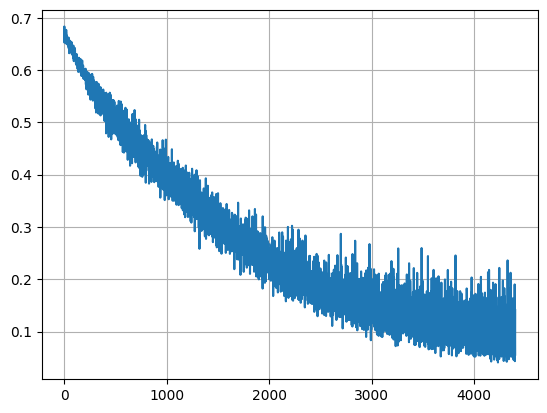

In [19]:
plt.plot(v_loss)
plt.grid()
plt.show()

In [20]:

# =====================
# 4. Avaliação
# =====================
model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        probs = model(xb)
        preds = (probs >= 0.5).float()
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true).flatten()
y_pred = np.array(y_pred).flatten()
y_prob = np.array(y_prob).flatten()


In [21]:

# métricas
f1 = f1_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
precision = precision_score(y_true, y_pred, average="macro")
accuracy = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
auc_pr = average_precision_score(y_true, y_prob)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
frr = fn / (fn + tp) if (fn + tp) > 0 else 0

print("\n=== Resultados ===")
print(f"F1-score (macro): {f1:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")
print(f"FRR: {frr:.4f}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))


=== Resultados ===
F1-score (macro): 0.9339
Recall (macro): 0.9435
Precision (macro): 0.9249
Accuracy: 0.9773
AUC-ROC: 0.9857
AUC-PR: 0.9297
FRR: 0.0980

Confusion Matrix:
 [[985  15]
 [ 10  92]]

Classification Report:
               precision    recall  f1-score   support

         0.0     0.9899    0.9850    0.9875      1000
         1.0     0.8598    0.9020    0.8804       102

    accuracy                         0.9773      1102
   macro avg     0.9249    0.9435    0.9339      1102
weighted avg     0.9779    0.9773    0.9776      1102



In [ ]:
macro avg     0.9237    0.9386    0.9310      1102
weighted avg     0.9769    0.9764    0.9766      1102